In [9]:
import pandas as pd

df = pd.read_csv('../data/raw_analyst_ratings.csv')  
df.head(10)


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A
5,5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22 11:23:25-04:00,A
6,6,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,2020-05-22 09:36:20-04:00,A
7,7,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16093805/a...,Benzinga Newsdesk,2020-05-22 09:07:04-04:00,A
8,8,Wells Fargo Maintains Overweight on Agilent Te...,https://www.benzinga.com/news/20/05/16093505/w...,vishwanath@benzinga.com,2020-05-22 08:37:59-04:00,A
9,9,10 Biggest Price Target Changes For Friday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-05-22 08:06:17-04:00,A


In [10]:
print(df.columns)


Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='object')


In [12]:
import pandas as pd

df = pd.read_csv("../data/raw_analyst_ratings.csv")

# Strip column names if there are spaces
df.columns = df.columns.str.strip()

# Select the needed columns
df = df[['date', 'headline', 'stock']]

# Convert 'date' column to datetime, forcing errors to NaT and then dropping those rows
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop rows where date conversion failed
df = df.dropna(subset=['date'])

# Optional: convert datetime to date only (without time)
df['date'] = df['date'].dt.date

print(df.head())


         date                                           headline stock
0  2020-06-05            Stocks That Hit 52-Week Highs On Friday     A
1  2020-06-03         Stocks That Hit 52-Week Highs On Wednesday     A
2  2020-05-26                      71 Biggest Movers From Friday     A
3  2020-05-22       46 Stocks Moving In Friday's Mid-Day Session     A
4  2020-05-22  B of A Securities Maintains Neutral on Agilent...     A


Cleaning the Headlines: We'll remove URLs, special characters, and convert text to lowercase.


In [15]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove non-letters
    text = text.lower()  # lowercase
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

df['headline'] = df['headline'].astype(str).apply(clean_text)
print(df[['headline']].head())


                                            headline
0               stocks that hit week highs on friday
1            stocks that hit week highs on wednesday
2                         biggest movers from friday
3            stocks moving in fridays midday session
4  b of a securities maintains neutral on agilent...


In [17]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove non-letters
    text = text.lower()  # lowercase
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

df['headline'] = df['headline'].astype(str).apply(clean_text)
cleaned_df = pd.read_csv("notebooks/processed_news/news_headlines_cleaned.csv")
cleaned_df = pd.read_csv("notebooks/processed_news/news_headlines_cleaned.csv")
print(cleaned_df.head())


         Date                                           headline stock  \
0  2020-06-05            Stocks That Hit 52-Week Highs On Friday     A   
1  2020-06-03         Stocks That Hit 52-Week Highs On Wednesday     A   
2  2020-05-26                      71 Biggest Movers From Friday     A   
3  2020-05-22       46 Stocks Moving In Friday's Mid-Day Session     A   
4  2020-05-22  B of A Securities Maintains Neutral on Agilent...     A   

                                    Cleaned_Headline  
0               stocks that hit week highs on friday  
1            stocks that hit week highs on wednesday  
2                         biggest movers from friday  
3            stocks moving in fridays midday session  
4  b of a securities maintains neutral on agilent...  


EDA on analyst headlines news

In [20]:
df = pd.read_csv("notebooks/processed_news/news_headlines_cleaned.csv")
print(df.columns)


Index(['Date', 'headline', 'stock', 'Cleaned_Headline'], dtype='object')


In [23]:
import pandas as pd

df = pd.read_csv("notebooks/processed_news/news_headlines_cleaned.csv", parse_dates=["Date"])


In [25]:
print(df.info())
print(df.describe())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   Date              1407328 non-null  datetime64[ns]
 1   headline          1407328 non-null  object        
 2   stock             1407328 non-null  object        
 3   Cleaned_Headline  1407324 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 42.9+ MB
None
                                Date
count                        1407328
mean   2015-08-22 01:18:13.919825152
min              2009-02-14 00:00:00
25%              2013-01-16 00:00:00
50%              2015-09-23 00:00:00
75%              2018-05-21 00:00:00
max              2020-06-11 00:00:00
        Date                                           headline stock  \
0 2020-06-05            Stocks That Hit 52-Week Highs On Friday     A   
1 2020-06-03         Stocks That Hit 52-Week 

In [26]:
print(df.isnull().sum())


Date                0
headline            0
stock               0
Cleaned_Headline    4
dtype: int64


In [30]:
print(df['stock'].value_counts().head(10))


stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64


 News count over time: Group and plot number of headlines per day:

In [28]:
df['headline_length'] = df['Cleaned_Headline'].apply(lambda x: len(str(x).split()))
print(df['headline_length'].describe())


count    1.407328e+06
mean     1.058142e+01
std      6.086434e+00
min      1.000000e+00
25%      7.000000e+00
50%      9.000000e+00
75%      1.200000e+01
max      7.300000e+01
Name: headline_length, dtype: float64


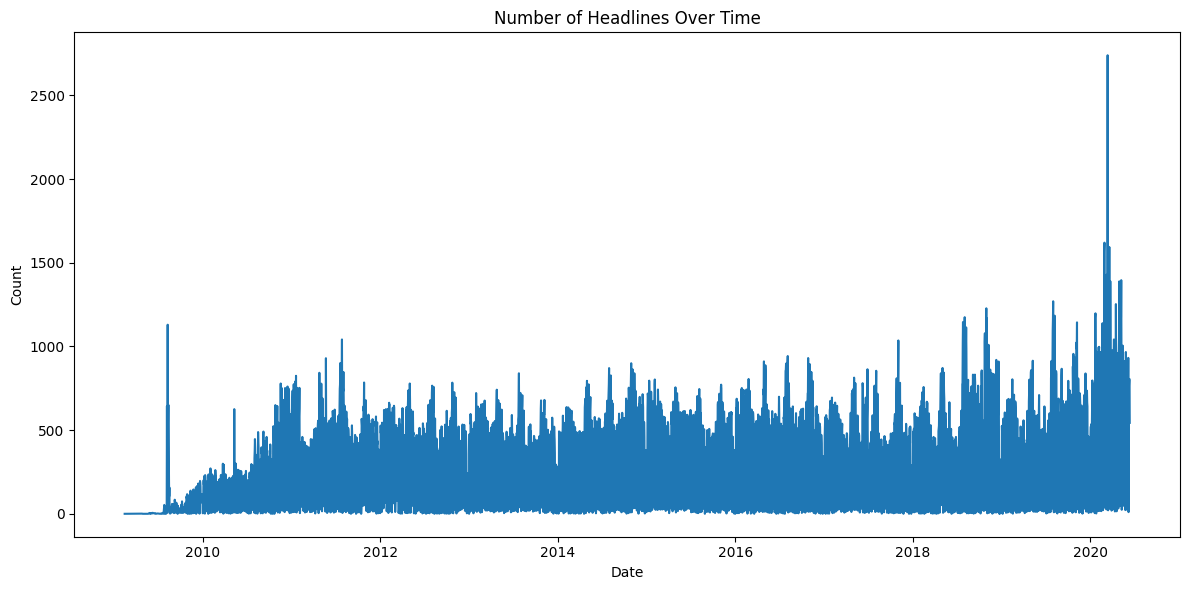

In [29]:
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])  # ensure it's datetime
daily_counts = df.groupby(df['Date'].dt.date).size()

plt.figure(figsize=(12, 6))
daily_counts.plot()
plt.title("Number of Headlines Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Sentiment Analysis: Install VADER for this purpose

In [31]:
pip install nltk


Note: you may need to restart the kernel to use updated packages.


In [2]:
import nltk
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

Run VADER on Cleaned Headlines

In [5]:
import pandas as pd

df = pd.read_csv("notebooks/processed_news/news_headlines_cleaned.csv", parse_dates=["Date"])


In [6]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Apply sentiment analysis
df['sentiment'] = df['Cleaned_Headline'].apply(lambda x: sia.polarity_scores(str(x))['compound'])


In [ ]:
Classify sentiments into catagories

In [9]:
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment'].apply(classify_sentiment)


In [10]:
print(df[['Cleaned_Headline', 'sentiment', 'sentiment_label']].head())


                                    Cleaned_Headline  sentiment  \
0               stocks that hit week highs on friday      0.000   
1            stocks that hit week highs on wednesday      0.000   
2                         biggest movers from friday      0.000   
3            stocks moving in fridays midday session      0.000   
4  b of a securities maintains neutral on agilent...      0.296   

  sentiment_label  
0         Neutral  
1         Neutral  
2         Neutral  
3         Neutral  
4        Positive  


Visualizing the sentiment distribution

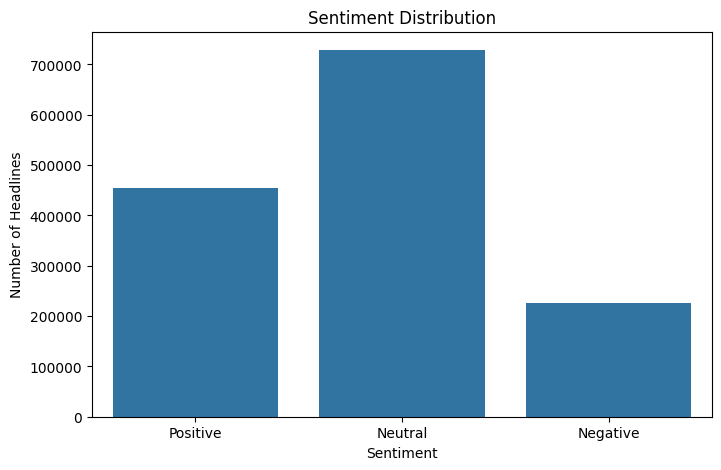

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment_label', order=['Positive', 'Neutral', 'Negative'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Headlines")
plt.show()


Calculating Daily Stock returns

In [19]:
daily_sentiment = df.groupby(['Date', 'stock'])['sentiment'].mean().reset_index()
daily_sentiment.rename(columns={'sentiment': 'avg_sentiment'}, inplace=True)


Loading Th yfinance folder

In [18]:
import os

price_data = []

for file in os.listdir("../data/yfinance_data"):
    if file.endswith(".csv"):
        stock_symbol = file.split('_')[0]
        df_price = pd.read_csv(os.path.join("../data/yfinance_data", file), parse_dates=['Date'])
        df_price['stock'] = stock_symbol
        df_price.sort_values(by='Date', inplace=True)
        df_price['daily_return'] = df_price['Close'].pct_change()
        price_data.append(df_price[['Date', 'stock', 'Close', 'daily_return']])


Combining all in one dataframe

In [17]:
price_df = pd.concat(price_data, ignore_index=True)


In [24]:
merged_df = pd.merge(daily_sentiment, price_df, on=['Date', 'stock'], how='inner')


In [25]:
merged_df.to_csv('merged_df.csv', index=False)


Correlation Analysis

In [21]:
correlation = merged_df['avg_sentiment'].corr(merged_df['daily_return'])
print(f"Correlation between sentiment and daily return: {correlation:.4f}")


Correlation between sentiment and daily return: 0.1882


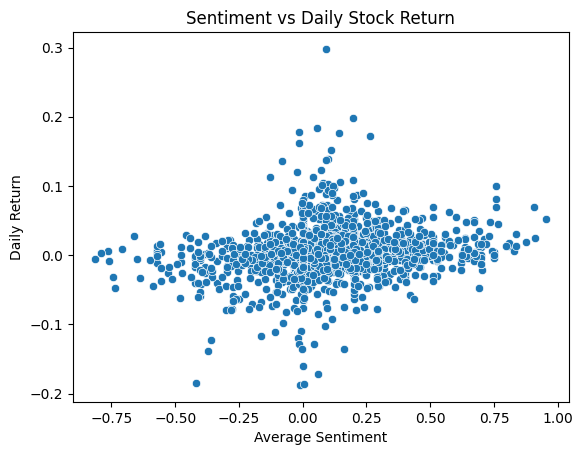

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='avg_sentiment', y='daily_return', data=merged_df)
plt.title('Sentiment vs Daily Stock Return')
plt.xlabel('Average Sentiment')
plt.ylabel('Daily Return')
plt.show()
